# ML Session 2 - Linear Regression

(100, 1) (100, 1)


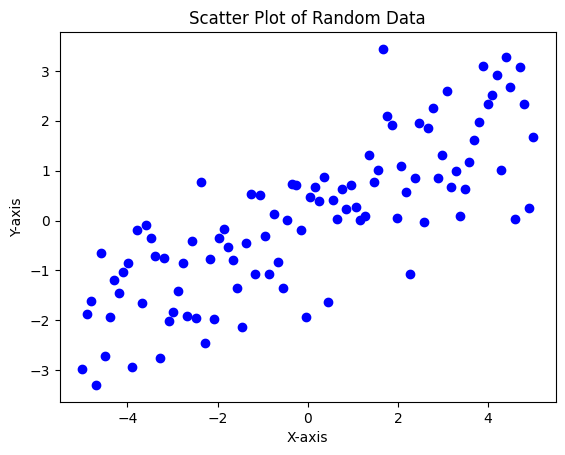

Initial Cost: 1.9321423263780018


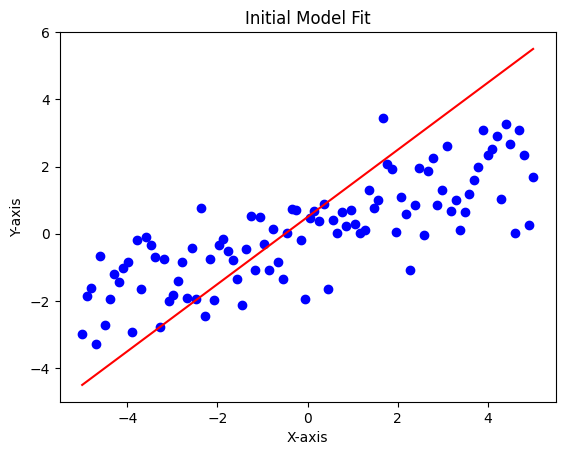

Final Weights: [[0.04737601 0.42555682]]
Final Cost: 0.42698536997194453


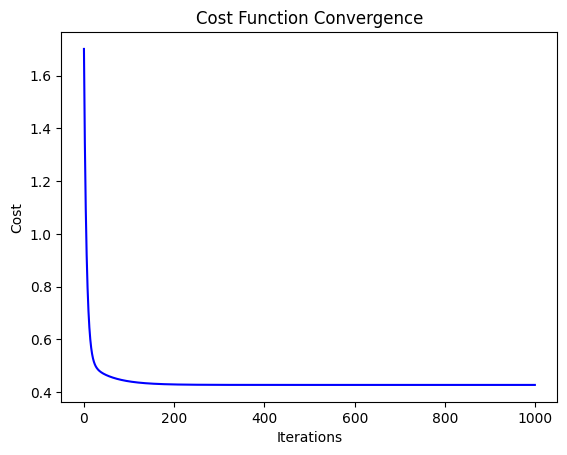

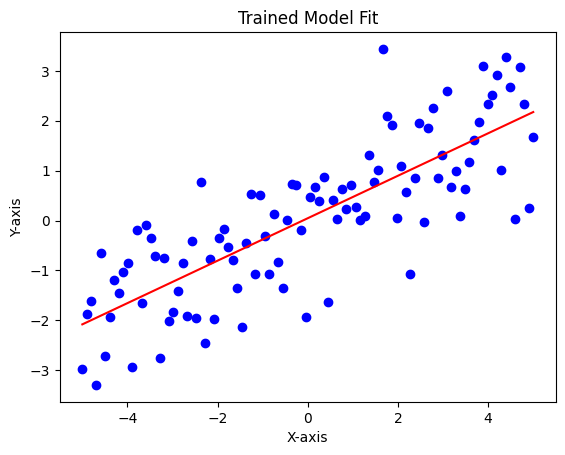

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-5, 5, 100)
y = np.random.randn(100) + 0.5 * x
x = x.reshape(-1, 1)
y = y.reshape(-1, 1)

print(x.shape, y.shape)

plt.scatter(x, y, color='blue', label='Data Points')
plt.title('Scatter Plot of Random Data')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.show()

def hypothesis(theta, x):
    return x.dot(theta.T)

# Initialize the weights
Theta = np.array([[0.5, 1]])
Theta = Theta.reshape(1, -1)
# Add intercept term to x
x = np.concatenate((np.ones((100, 1)), x), axis=1)

initial_predictions = hypothesis(Theta, x)
# print(initial_predictions)

def cost_function(x, y, theta):
    m = len(y)
    predictions = hypothesis(theta, x)
    cost = (1 / (2 * m) * np.sum(np.square(predictions - y)))
    return cost

initial_cost = cost_function(x, y, Theta)
print(f'Initial Cost: {initial_cost}')


# Initial model visualization
plt.scatter(x[:, 1], y, color='blue', label='Data Points')
plt.plot(x[:, 1], initial_predictions, color='red', label='Initial Model')
plt.title('Initial Model Fit')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.show()

# Gradient Descent
def gradient_descent(x, y, theta, learning_rate=0.0001, iterations=100):
    m = len(y)
    cost_history = np.zeros(iterations)
    for i in range(iterations):
        predictions = hypothesis(theta, x)
        errors = predictions - y
        theta = theta - (learning_rate / m) * (x.T.dot(errors)).T
        cost_history[i] = cost_function(x, y, theta)

    return theta, cost_history
    
learning_rate = 0.01
iterations = 1000
Theta_final, cost_history = gradient_descent(x, y, Theta, learning_rate, iterations)
print(f'Final Weights: {Theta_final}')
final_cost = cost_function(x, y, Theta_final)
print(f'Final Cost: {final_cost}')

# cost history visualization
plt.plot(range(iterations), cost_history, color='blue')
plt.title('Cost Function Convergence')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.show()

# Trained model visualization
final_predictions = hypothesis(Theta_final, x)
plt.scatter(x[:, 1], y, color='blue', label='Data Points')
plt.plot(x[:, 1], final_predictions, color='red', label='Trained Model')
plt.title('Trained Model Fit')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.show()


# Using sklearn

Sklearn Weights: Intercept = [0.04735646], Slope = [[0.42555682]]
Sklearn Mean Squared Error: 0.8539707395620313


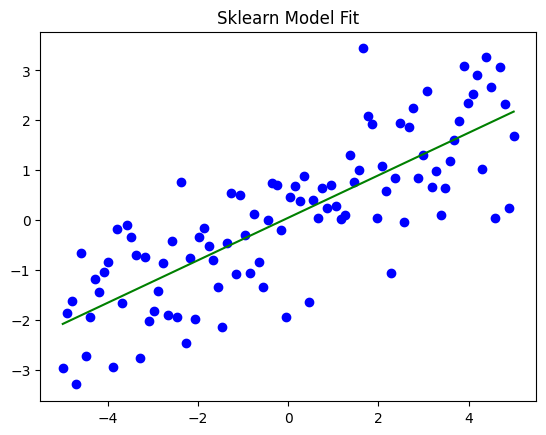

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error 

lr = LinearRegression()
lr.fit(x[:, 1].reshape(-1, 1), y)
print(f'Sklearn Weights: Intercept = {lr.intercept_}, Slope = {lr.coef_}')

MSE = mean_squared_error(y, lr.predict(x[:, 1].reshape(-1, 1)))
print(f'Sklearn Mean Squared Error: {MSE}')

# Sklearn model visualization
plt.scatter(x[:, 1], y, color='blue', label='Data Points')
plt.plot(x[:, 1], lr.predict(x[:, 1].reshape(-1, 1)), color='green', label='Sklearn Model')
plt.title('Sklearn Model Fit')
plt.show()